# Import Libraries & Load Data

In [277]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning

from utils import engine

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [278]:
# load the dataset
model_df = pd.read_sql(
    "SELECT * FROM predict_df",
    engine
)

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 26 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   country                                           54 non-null     object 
 1   year                                              54 non-null     int64  
 2   milk_prod_1000t                                   54 non-null     float64
 3   butter_prod_1000t                                 54 non-null     float64
 4   cheese_prod_1000t                                 54 non-null     float64
 5   milk_powder_prod_1000t                            49 non-null     float64
 6   milk_delivered_to_dairies_1000t                   54 non-null     float64
 7   milk_per_cow                                      54 non-null     float64
 8   dairy_cow_pop_1000                                54 non-null     float64
 9   bovine_pop_1000        

# Feature Selection

The aim is to predict the total_dairy_export_value_1000USD of all selected countries. First, lets visualize it over time.

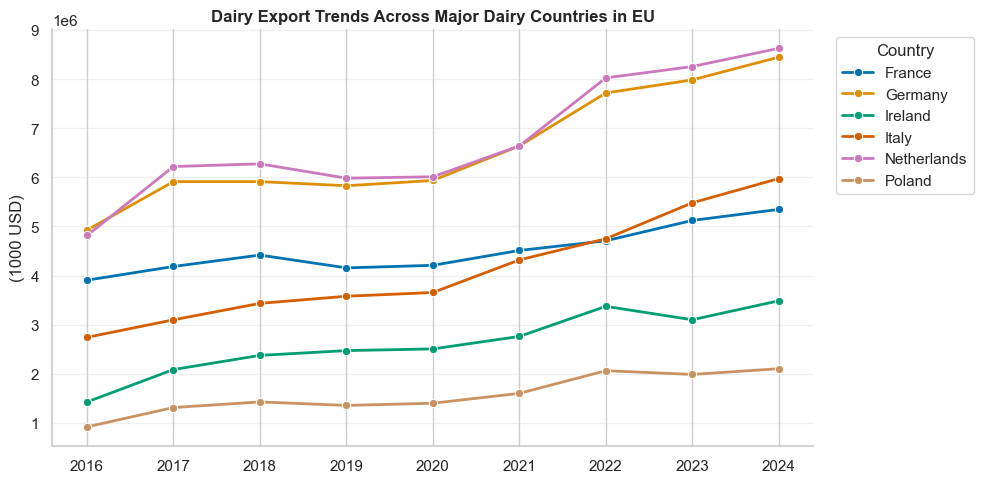

In [279]:
plt.figure(figsize=(10,5))

sns.lineplot(data=model_df,x='year',y='total_dairy_export_value_1000USD',hue='country',linewidth=2,marker='o')

plt.title("Dairy Export Trends Across Major Dairy Countries in EU", fontsize=12, weight="semibold")
plt.xlabel("")
plt.ylabel("(1000 USD)")
plt.legend(title="Country",bbox_to_anchor=(1.02, 1),loc="upper left")

sns.despine()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

In [316]:
model_df.head()

,country,year,milk_prod_1000t,butter_prod_1000t,cheese_prod_1000t,milk_powder_prod_1000t,milk_delivered_to_dairies_1000t,milk_per_cow,dairy_cow_pop_1000,bovine_pop_1000,...,Whole milk powder_Export value_1000 USD,total_dairy_export_value_1000USD,export_per_cow,output_per_labour,milk_prod_growth_pct,export_growth_pct,lag_export_value,dairy_cow_share,milk_delivery_ratio,export_per_subsidy
0,France,2017,26006.31,412.72,1919.57,504.57,24629.49,7.230322,3596.84,19432.72,...,295481.0,4184732.0,1163.446803,98.104203,-0.228575,7.144335,3905696.0,0.185092,0.947058,581.736203
1,France,2018,26022.50,417.41,1907.76,451.82,24542.54,7.321558,3554.23,18736.99,...,274410.0,4417132.0,1242.781700,105.440560,0.062254,5.553522,4184732.0,0.189691,0.943128,636.935806
2,France,2019,26036.29,419.22,1903.29,470.06,24526.30,7.458524,3490.81,18469.77,...,253199.0,4156105.0,1190.584707,105.851916,0.052993,-5.909423,4417132.0,0.189001,0.942004,601.477793
3,France,2020,26288.53,417.54,1862.10,486.48,24602.21,7.719025,3405.68,18200.48,...,290181.0,4208091.0,1235.609629,104.625639,0.968802,1.250835,4156105.0,0.187120,0.935853,618.130994
4,France,2021,25829.08,410.18,1879.63,466.84,24199.49,7.775089,3322.03,17862.57,...,335603.0,4510801.0,1357.844752,113.796899,-1.747720,7.193523,4208091.0,0.185977,0.936909,658.168290


In [317]:
model_df.columns

Index(['country', 'year', 'milk_prod_1000t', 'butter_prod_1000t',
       'cheese_prod_1000t', 'milk_powder_prod_1000t',
       'milk_delivered_to_dairies_1000t', 'milk_per_cow', 'dairy_cow_pop_1000',
       'bovine_pop_1000', 'total_labour_awu',
       'agri_output_basic_price_million_eur',
       'cap_direct_payments_million_eur',
       'Raw milk of cattle_Export value_1000 USD',
       'Butter of cow milk_Export value_1000 USD',
       'Cheese from whole cow milk_Export value_1000 USD',
       'Whole milk powder_Export value_1000 USD',
       'total_dairy_export_value_1000USD', 'export_per_cow',
       'output_per_labour', 'milk_prod_growth_pct', 'export_growth_pct',
       'lag_export_value', 'dairy_cow_share', 'milk_delivery_ratio',
       'export_per_subsidy'],
      dtype='object')

The dataset represents a pooled multi-country dairy export panel where each observation corresponds to a country-year combination. Therefore, the models will be trained to learn both shared export relationships across EU dairy economies and country-specific structural variation, respectively.

Now, to select candidate features, we are not considering the following features because they are bascically components of the target variable:
- "Raw milk of cattle_Export value_1000 USD",
- "Butter of cow milk_Export value_1000 USD",
- "Cheese from whole cow milk_Export value_1000 USD",
- "Whole milk powder_Export value_1000 USD"

Similarly, the following variables are directly derived from the target variable so they will be not considered either.
- "export_per_cow" and
- "export_growth_pct"

In [281]:
target = "total_dairy_export_value_1000USD"

candidate_features = [

    # Production variables
    "milk_prod_1000t",
    "milk_delivered_to_dairies_1000t",
    "butter_prod_1000t",
    "cheese_prod_1000t",
    "milk_powder_prod_1000t",

    # Livestock variables
    "dairy_cow_pop_1000",
    "bovine_pop_1000",

    # Economic
    "agri_output_basic_price_million_eur",
    "cap_direct_payments_million_eur",

    # Labour/Productivity variables
    "total_labour_awu",
    "output_per_labour",

    # Efficiency variables
    "milk_per_cow",
    "dairy_cow_share",

    # Temporal variables
    "lag_export_value",
    "milk_prod_growth_pct"
    
]

Before proceeding into modelling, lets first check the correlation among candidate features and target feature using heatmap visualization.

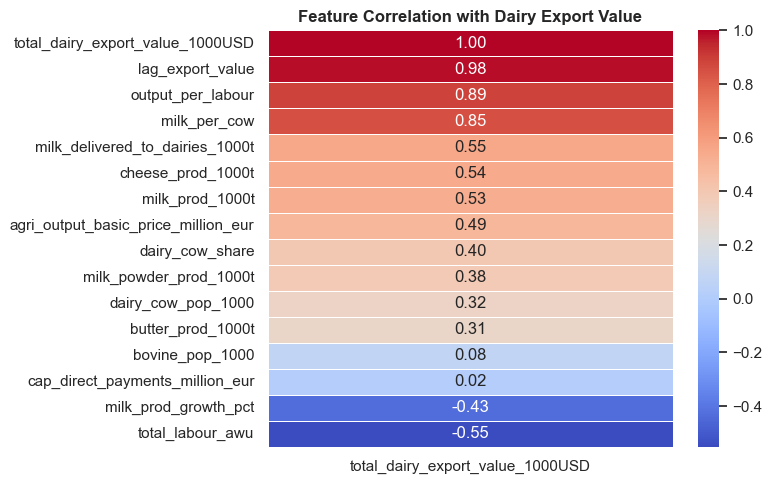

In [282]:
corr_target = (
    model_df[candidate_features + [target]]
    .corr(numeric_only=True)[target]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation with Dairy Export Value",fontsize=12,weight="semibold")
plt.tight_layout()

The heatmap shows that dairy export value is strongly associated with temporal and productivity-related variables. `lag_export_value`, `output_per_labour`, and `milk_per_cow` exhibited the strongest positive relationships, indicating that historical export performance, labour efficiency, and milk productivity are major drivers of dairy export competitiveness.

Production-related variables such as `milk_delivered_to_dairies_1000t`, `cheese_prod_1000t`, and `milk_prod_1000t` also showed moderate positive relationships, while variables such as `cap_direct_payments_million_eur` and `bovine_pop_1000` demonstrated weak relationships with the target variable.

Therefore, for now, the following features are selected for modelling. We can ammend the feature sets as needed in the future.

In [283]:
selected_features = [

    # Temporal
    "lag_export_value",

    # Productivity / efficiency
    "output_per_labour",
    "milk_per_cow",

    # Production
    "milk_delivered_to_dairies_1000t",
    "cheese_prod_1000t",
    "milk_prod_1000t",

    # Economic
    "agri_output_basic_price_million_eur",

    # Structural
    "dairy_cow_share"
]
model_df[selected_features + [target]].isna().sum().sort_values(ascending=False)

lag_export_value                       6
output_per_labour                      0
milk_per_cow                           0
milk_delivered_to_dairies_1000t        0
cheese_prod_1000t                      0
milk_prod_1000t                        0
agri_output_basic_price_million_eur    0
dairy_cow_share                        0
total_dairy_export_value_1000USD       0
dtype: int64

In [284]:
# Dropping nan values introduced by lag feature
model_df = model_df.dropna(subset=selected_features + [target]).reset_index(drop=True)

# Train-Test Split

Since the dataset is structured as country-year observations, a year-based chronological split was used instead of a random split. This avoids training the model on future observations and provides a more realistic forecasting setup.

The model will be trained on observations from 2017 to 2022 and tested on 2023 to 2024.

In [287]:
# Split data by year to preserve chronological order
train_df = model_df[model_df["year"] <= 2022].copy()
test_df = model_df[model_df["year"] > 2022].copy()

# Separate features and target
X_train = train_df[selected_features]
X_test = test_df[selected_features]

y_train = train_df[target]
y_test = test_df[target]

# Display train-test shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Confirm year ranges
print("Training years:", train_df["year"].min(), "to", train_df["year"].max())
print("Testing years:", test_df["year"].min(), "to", test_df["year"].max())

X_train shape: (36, 8)
X_test shape: (12, 8)
y_train shape: (36,)
y_test shape: (12,)
Training years: 2017 to 2022
Testing years: 2023 to 2024


# Model Development


## Feature Scaling
Firstly, before applying feature scaling, the distributions of the selected features will be analyzed to assess skewness, spread, and the presence of outliers to decide  which scalar will be most suited.

In [288]:
# Summary stats table
X_train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
lag_export_value,3.859696e+06,1.794729e+06,919246.000000,6.639209e+06
output_per_labour,9.809814e+01,6.565845e+01,14.609953,2.588143e+02
milk_per_cow,7.495010e+00,1.162525e+00,5.582476,9.543885e+00
milk_delivered_to_dairies_1000t,1.723772e+04,8.449016e+03,7475.420000,3.254898e+04
cheese_prod_1000t,1.271134e+03,6.846539e+02,219.900000,2.360900e+03
milk_prod_1000t,1.833499e+04,8.474116e+03,7498.940000,3.318889e+04
agri_output_basic_price_million_eur,4.522849e+04,2.465926e+04,8498.240000,9.726911e+04
dairy_cow_share,2.976725e-01,8.292810e-02,0.182427,4.240034e-01


In [289]:
# Checking skewness of selected features
X_train.skew().sort_values(ascending=False)

milk_delivered_to_dairies_1000t        0.824506
output_per_labour                      0.704180
milk_prod_1000t                        0.680196
milk_per_cow                           0.181185
cheese_prod_1000t                      0.130265
agri_output_basic_price_million_eur    0.108704
lag_export_value                      -0.019872
dairy_cow_share                       -0.220354
dtype: float64

Lets further visualize the distribution and outliers as well

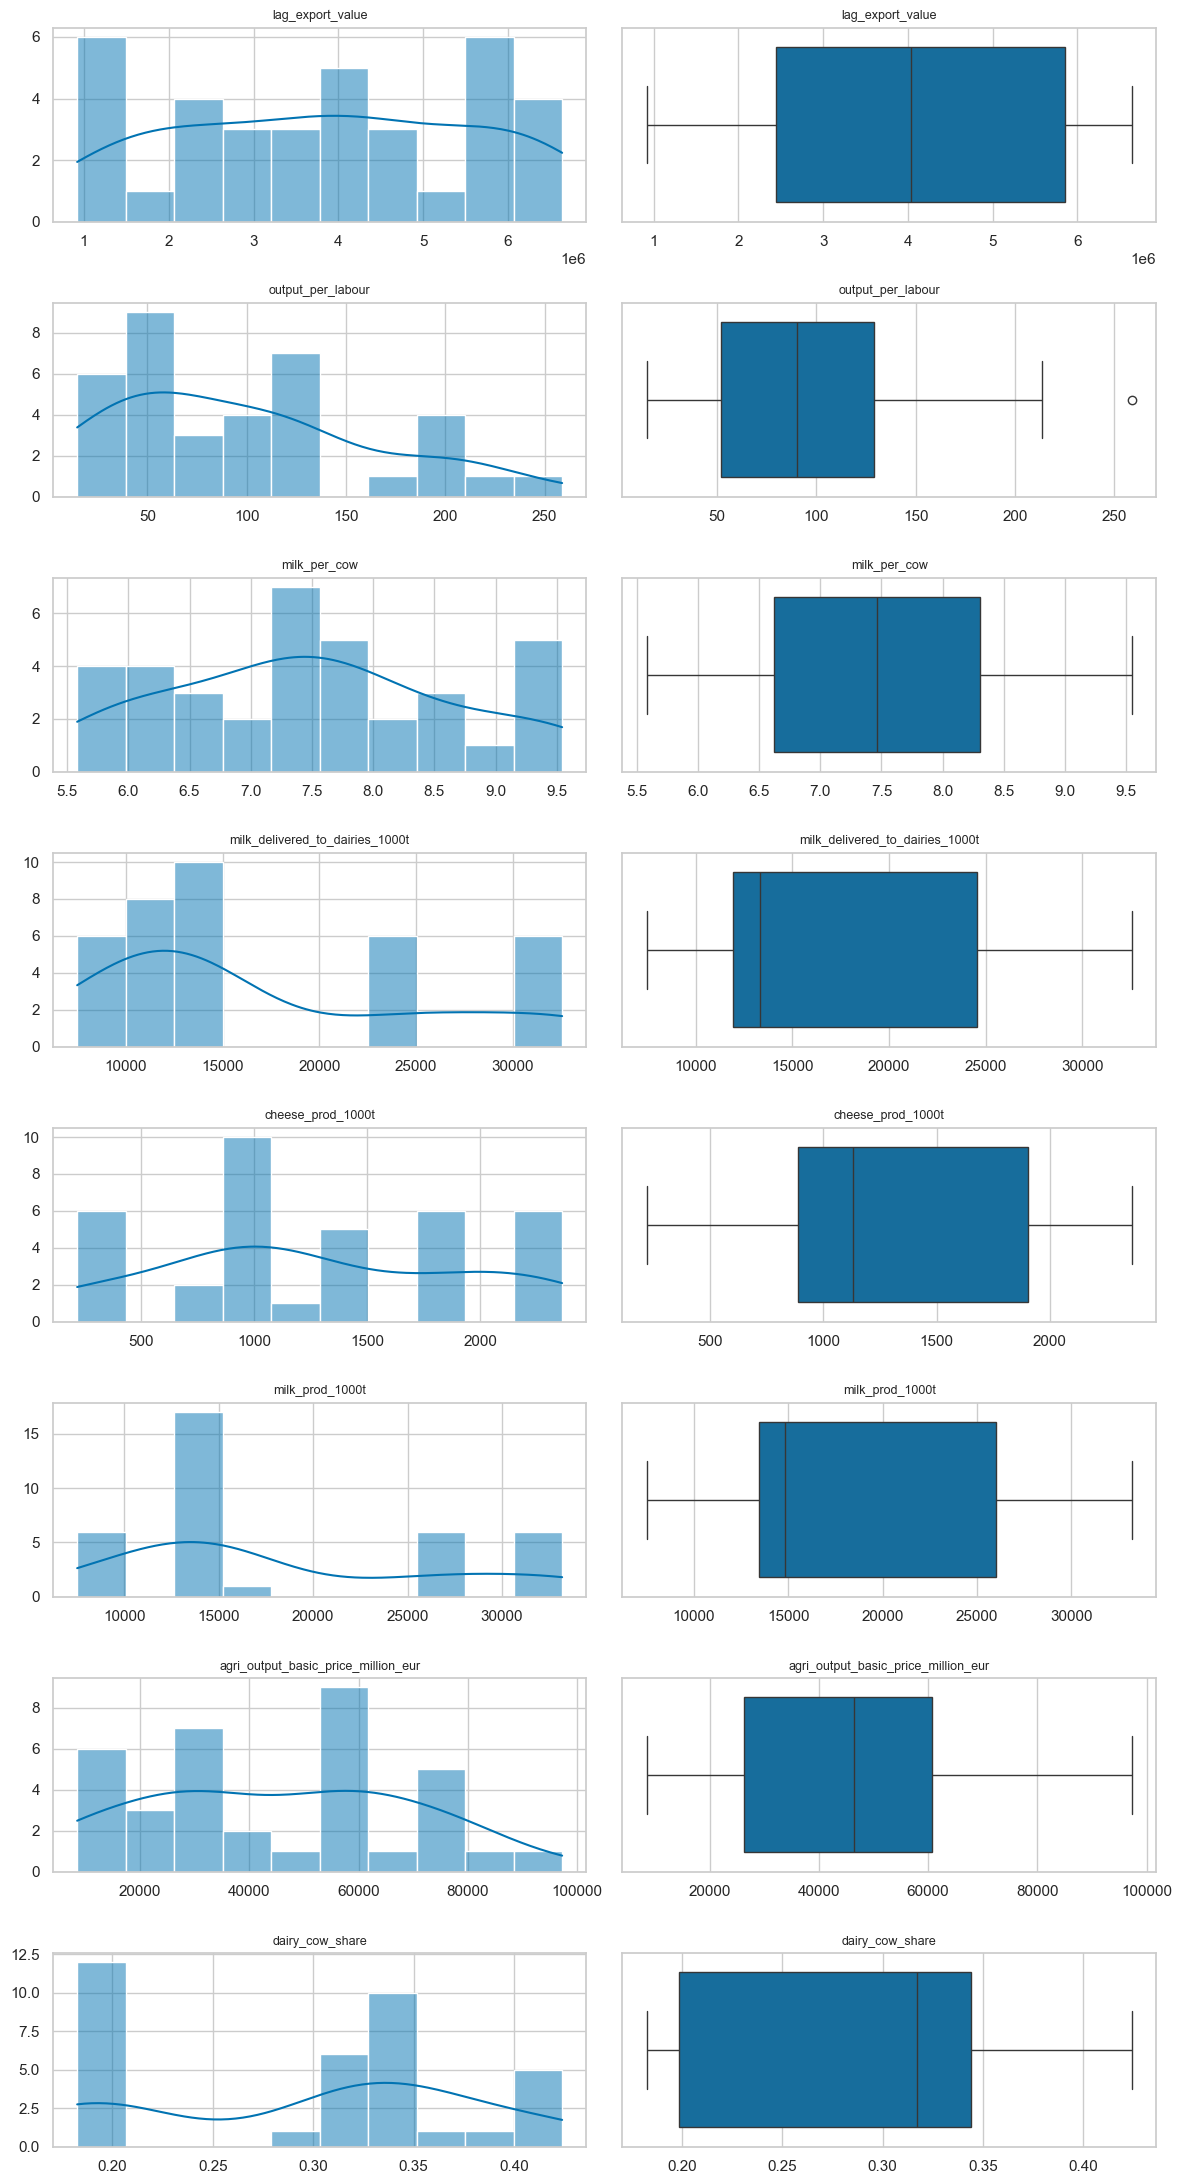

In [290]:
fig, axes = plt.subplots(len(selected_features), 2, figsize=(12, 22))

for i, col in enumerate(selected_features):

    # Histogram with KDE for distribution shape
    sns.histplot(
        data=X_train,
        x=col,
        kde=True,
        bins=10,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{col}", fontsize=9)
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("")

    # Boxplot for outlier inspection
    sns.boxplot(
        data=X_train,
        x=col,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{col}", fontsize=9)
    axes[i, 1].set_xlabel("")

plt.tight_layout()

### Observation

The summary statistics show that the selected features exist on substantially different numerical scales justifying the need for scalars. The skewness analysis and distribution visualizations further indicate that the selected features are not consistently close to normal overall. Variables such as `milk_delivered_to_dairies_1000t`, `output_per_labour`, and `milk_prod_1000t` exhibit mild to moderate right skewness. The boxplots also reveal limited outlier behaviour, primarily within `output_per_labour`, although no feature appears to contain extreme outlier dominance.

Based on the preprocessing guidelines discussed in eda class:

- `StandardScaler` is generally more appropriate for variables closer to a normal distribution.
- `MinMaxScaler` can be useful when variables are skewed and need range normalization.
- `RobustScaler` is more suitable when outliers are present because it is less sensitive to extreme values.

Since the current feature set contains a mixture of mild skewness, different feature scales, and some outlier behaviour, multiple scaling approaches will be experimentally compared for scale-sensitive models rather than assuming a single scaler is optimal.

Therefore, `No Scaling`, `StandardScaler`, `MinMaxScaler`, and `RobustScaler` will be evaluated. Each scaler will be fitted only on the training set and then applied to the test set to prevent data leakage.

Although feature-specific preprocessing was considered, a uniform preprocessing strategy is preferred due to the relatively small dataset size and the need to maintain workflow simplicity.


In [ ]:
Lets start by constructing reusable functions.

In [291]:
# Function to evaluate regression model performance
def evaluate_regression_model(model_name, experiment_name, y_true, y_pred):

    mse = mean_squared_error(y_true, y_pred)

    return {
        "Model": model_name,
        "Experiment": experiment_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2 Score": r2_score(y_true, y_pred)
    }

In [292]:
# Reusable function to train and evaluate multiple models
def run_model_experiment(models_dict, X_train, X_test, y_train, y_test, experiment_name):

    results = []

    for model_name, model in models_dict.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append(
            evaluate_regression_model(
                model_name=model_name,
                experiment_name=experiment_name,
                y_true=y_test,
                y_pred=y_pred
            )
        )

    return (
        pd.DataFrame(results)
        .sort_values(by=["R2 Score", "RMSE"], ascending=[False, True])
        .reset_index(drop=True)
    )

In [293]:
def run_scaler_experiment(models_dict, scalers_dict, X_train, X_test, y_train, y_test):

    scaler_results = []

    for model_name, model in models_dict.items():
        for scaler_name, scaler in scalers_dict.items():

            if scaler is None:
                X_train_used = X_train
                X_test_used = X_test
            else:
                X_train_used = scaler.fit_transform(X_train)
                X_test_used = scaler.transform(X_test)

            model.fit(X_train_used, y_train)
            y_pred = model.predict(X_test_used)

            scaler_results.append(
                evaluate_regression_model(
                    model_name=model_name,
                    experiment_name=scaler_name,
                    y_true=y_test,
                    y_pred=y_pred
                )
            )

    return (
        pd.DataFrame(scaler_results)
        .rename(columns={"Experiment": "Scaler"})
        .sort_values(by=["R2 Score", "RMSE"], ascending=[False, True])
        .reset_index(drop=True)
    )

In [294]:
scaler_results_df = run_scaler_experiment(
    models_dict=scale_sensitive_models,
    scalers_dict=scalers,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

scaler_results_df

,Model,Scaler,MAE,MSE,RMSE,R2 Score
0,Ridge,StandardScaler,3.646182e+05,2.268543e+11,4.762923e+05,0.958936
1,ElasticNet,No Scaling,4.998666e+05,4.282286e+11,6.543918e+05,0.922483
2,Ridge,RobustScaler,4.924243e+05,4.289084e+11,6.549110e+05,0.922360
3,Lasso,MinMaxScaler,5.228927e+05,4.662296e+11,6.828101e+05,0.915605
4,Lasso,RobustScaler,5.231007e+05,4.665427e+11,6.830393e+05,0.915548
5,Lasso,StandardScaler,5.231547e+05,4.666247e+11,6.830993e+05,0.915533
6,Lasso,No Scaling,5.232796e+05,4.668091e+11,6.832343e+05,0.915500
7,Linear Regression,RobustScaler,5.232806e+05,4.668148e+11,6.832384e+05,0.915499
8,Linear Regression,MinMaxScaler,5.232806e+05,4.668148e+11,6.832384e+05,0.915499
9,Linear Regression,StandardScaler,5.232806e+05,4.668148e+11,6.832384e+05,0.915499


### Observation
The scaler comparison shows that preprocessing affects models differently depending on how each algorithm learns from the feature space.

`Ridge Regression` performed best with `StandardScaler`, which is expected because Ridge applies an L2 penalty to coefficients. When features are on very different scales, the penalty can affect variables unevenly. Standardization places features on a comparable scale, allowing Ridge to regularize the coefficients more fairly and generalize better.`Lasso Regression` produced very similar results across scaling methods, suggesting that the selected feature set is not strongly affected by sparsity-based feature removal. Since Lasso uses L1 regularization, it can shrink some coefficients strongly, but in this dataset the main predictive signal appears distributed across several features rather than concentrated in one removable variable.`ElasticNet` performed best without scaling, which suggests that the original economic magnitudes may contain useful variance structure for this dataset. However, because ElasticNet combines L1 and L2 penalties, its sensitivity to scaling also shows that its behaviour is less stable than Ridge for this feature set.`KNN` and `SVR` performed weaker overall. This is likely because KNN depends on distance between observations, while SVR depends on margins and kernel behaviour. With only 48 observations and might be strong temporal persistence in the target, these algorithms do not have enough dense or complex feature structure to outperform the simpler regularized linear models.

Based on these findings, `StandardScaler` will be adopted as the primary preprocessing strategy for best performing scale-sensitive models in the next modelling stage, while tree-based models will continue using the original feature space.

## Final Baseline Models

In [318]:
baseline_models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=10000, random_state=42))
    ]),
    
    "ElasticNet": Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        max_iter=10000,
        random_state=42))
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
}

In [319]:
baseline_results_df = run_model_experiment(
    models_dict=baseline_models,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    experiment_name="Baseline"
)

baseline_results_df

,Model,Experiment,MAE,MSE,RMSE,R2 Score
0,Ridge,Baseline,364618.159360,2.268543e+11,476292.274744,0.958936
1,Decision Tree,Baseline,449324.266667,2.893400e+11,537903.345270,0.947625
2,Lasso,Baseline,523154.735693,4.666247e+11,683099.347180,0.915533
3,Linear Regression,Baseline,523280.562178,4.668148e+11,683238.432851,0.915499
4,Random Forest,Baseline,686154.919658,6.073418e+11,779321.378492,0.890061
5,ElasticNet,Baseline,780065.697728,7.741037e+11,879831.642268,0.859874


### Observation

The baseline comparison shows that regularized linear models performed strongest overall on the selected dairy export features.

- `Ridge Regression` achieved the best predictive performance with the lowest RMSE and highest R² score. This indicates that the selected dairy export features contain strong linear relationships while also exhibiting some multicollinearity, which Ridge handles effectively through L2 regularization.

- `Decision Tree Regression` also performed strongly despite its constrained depth. This suggests that some nonlinear threshold-based relationships exist within the dairy export system. However, its slightly weaker performance compared with Ridge indicates that these nonlinear patterns are not dominant across the dataset.

- `Lasso Regression` and `Linear Regression` produced nearly identical results. This suggests that the current feature set does not contain a large number of redundant or irrelevant variables requiring aggressive feature shrinkage.

- `Random Forest` achieved weaker performance than Ridge and Decision Tree models. Although ensemble learning can capture complex nonlinear feature interactions, Random Forest typically benefits from larger datasets with more diverse patterns. In this project, the relatively small country-year panel limits the amount of variation available for bagging-based learning.

- `ElasticNet` underperformed relative to Ridge and Lasso. This suggests that combining both L1 and L2 penalties did not provide substantial additional benefit for the current feature structure.

# Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning will be applied only to models that demonstrated strong baseline performance and whose learning behaviour is sensitive to parameter configuration. `GridSearchCV` iss selected because the dataset is relatively small and the hyperparameter search space is limited. Therefore, an exhaustive search approach is computationally feasible while ensuring that all candidate parameter combinations are systematically evaluated. Also,  `TimeSeriesSplit` strategy will be integrated within GridSearchCV to preserve chronological ordering during validation. 


In [324]:
# Time-aware cross-validation to preserve chronological order
tscv = TimeSeriesSplit(n_splits=3)

# Models selected for hyperparameter tuning
tuning_models = {
    "Ridge": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },

    "Lasso": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=10000, random_state=42))
        ]),
        "params": {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        "params": {
            "model__max_depth": [2, 3, 4, 5],
            "model__min_samples_leaf": [1, 2, 3]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [2, 3, 4],
            "model__min_samples_leaf": [1, 2, 3]
        }
    }
}

In [325]:

# Tune selected models using GridSearchCV
tuned_results = []
best_models = {}

for model_name, model_info in tuning_models.items():

    grid_search = GridSearchCV(
        estimator=model_info["pipeline"],
        param_grid=model_info["params"],
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    best_models[model_name] = best_model

    result = evaluate_regression_model(
        model_name=model_name,
        experiment_name="Tuned",
        y_true=y_test,
        y_pred=y_pred
    )

    result["Best Parameters"] = grid_search.best_params_
    result["CV RMSE"] = -grid_search.best_score_

    tuned_results.append(result)

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values(by=["R2 Score", "RMSE"], ascending=[False, True])
    .reset_index(drop=True)
)

tuned_results_df

,Model,Experiment,MAE,MSE,RMSE,R2 Score,Best Parameters,CV RMSE
0,Random Forest,Tuned,581867.737499,4.541349e+11,673895.308627,0.917794,"{'model__max_depth': 4, 'model__min_samples_le...",1.450647e+06
1,Lasso,Tuned,523154.735693,4.666247e+11,683099.347180,0.915533,{'model__alpha': 1},1.594700e+06
2,Ridge,Tuned,645632.119956,5.533989e+11,743907.866963,0.899825,{'model__alpha': 10},8.436709e+05
3,Decision Tree,Tuned,664603.781481,6.206693e+11,787825.674776,0.887648,"{'model__max_depth': 3, 'model__min_samples_le...",1.132485e+06


### Observation

The tuning results indicate that additional hyperparameter optimization provided limited improvement over the already strong baseline models observed earlier.

- `Random Forest` showed the largest tuning improvement, suggesting that controlling tree depth and leaf size helped reduce overfitting from overly complex ensemble structures. However, the model still remained weaker than the best linear approaches, indicating that nonlinear interactions are not the dominant source of predictive signal in the dataset.

- `Lasso Regression` produced almost identical results before and after tuning. This suggests that the selected feature set already contains mostly meaningful predictors, leaving little benefit from stronger coefficient shrinkage or automatic feature elimination.

- `Ridge Regression` experienced weaker test performance after tuning despite achieving the lowest cross-validation RMSE. This highlights that strong cross-validation performance does not always translate into superior future-year generalization on small temporal datasets.

- `Decision Tree Regression` remained the weakest among the tuned models. The instability of single-tree learning on small country-year datasets likely caused sensitivity to fold-specific temporal patterns, reducing generalization consistency.


# Naive Benchmark

Since `lag_export_value` showed an extremely strong relationship with the target variable in earlier analysis, a naive forecasting benchmark will also evaluated. This will help determine whether the  models are genuinely learning additional economic and production patterns beyond simple temporal persistence.

*The naive benchmark predicts the current export value using the previous year's export value.*

In [299]:
# Prepare naive forecast benchmark
naive_result = evaluate_regression_model(
    model_name="Naive Forecast",
    experiment_name="Benchmark",
    y_true=y_test,
    y_pred=X_test["lag_export_value"]
)

naive_results_df = pd.DataFrame([naive_result])

In [300]:
# Prepare naive forecast benchmark
naive_result = evaluate_regression_model(
    model_name="Naive Forecast",
    experiment_name="Benchmark",
    y_true=y_test,
    y_pred=X_test["lag_export_value"]
)

# Convert benchmark result into dataframe
naive_results_df = pd.DataFrame([naive_result])

naive_results_df

,Model,Experiment,MAE,MSE,RMSE,R2 Score
0,Naive Forecast,Benchmark,337284.583333,1.433440e+11,378607.946481,0.974052


### Observation

The naive forecast benchmark achieved the strongest performance, outperforming all machine learning models. Although as seen Ridge Regression performed best among the machine learning baseline models, it still did not outperform the naive benchmark. This suggests that the additional production, productivity, and economic features improve interpretation, but they may not add enough predictive value beyond the lagged export value.
Therefore, model performance should not be judged only by high R² values. The comparison with the naive benchmark shows that a simpler forecasting rule may be more effective than more complex ML models for short-term prediction.

# Lag Feature Sensitivity Analysis

Lets compares model performance before and after removing the lag feature from the feature set. The objective is to determine whether the machine learning models are learning broader dairy production and economic relationships, or only relying on temporal persistence from previous export values.

In [301]:
# Remove lag feature for sensitivity analysis
features_without_lag = [
    feature for feature in selected_features
    if feature != "lag_export_value"
]

X_train_no_lag = train_df[features_without_lag]
X_test_no_lag = test_df[features_without_lag]

In [302]:
# Models selected for lag sensitivity analysis
lag_sensitivity_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=3,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    )
}

In [303]:
# Evaluate models without lag feature
lag_results_df = run_model_experiment(
    models_dict=lag_sensitivity_models,
    X_train=X_train_no_lag,
    X_test=X_test_no_lag,
    y_train=y_train,
    y_test=y_test,
    experiment_name="Without Lag"
)

lag_results_df

,Model,Experiment,MAE,MSE,RMSE,R2 Score
0,Ridge,Without Lag,8.743451e+05,1.172652e+12,1.082891e+06,0.787730
1,Random Forest,Without Lag,1.115017e+06,1.576491e+12,1.255584e+06,0.714629
2,Decision Tree,Without Lag,1.400749e+06,3.146643e+12,1.773878e+06,0.430405


### Observation

Removing the `lag_export_value` feature caused a noticeable reduction in predictive performance. However, the models still retained moderate predictive capability after removing the lag feature. Ridge Regression continued to achieve an R² score close to 0.79, indicating that the remaining  variables still contain meaningful predictive information.

# Structural enhancement using encoded country feature

The previous regression experiments were performed using only numerical-related variables. However, the dataset represents multiple EU dairy-producing countries. Therefore, country identity itself may contain useful predictive information that is not fully captured through numerical variables alone.

To evaluate this, the categorical country feature will now be incorporated into the workflow using one-hot encoding as the country variable does not contain any natural ordinal relationship. Therefore, one-hot encoding is applied so that each country becomes a separate binary feature, allowing the models to learn country-specific structural patterns without introducing artificial ordering between categories.


In [304]:
# Add country as a categorical structural feature
country_features = selected_features + ["country"]

X_train_country = train_df[country_features]
X_test_country = test_df[country_features]

numeric_features = selected_features
categorical_features = ["country"]

X_train_country.head()

,lag_export_value,output_per_labour,milk_per_cow,milk_delivered_to_dairies_1000t,cheese_prod_1000t,milk_prod_1000t,agri_output_basic_price_million_eur,dairy_cow_share,country
0,3905696.0,98.104203,7.230322,24629.49,1919.57,26006.31,73152.38,0.185092,France
1,4184732.0,105.440560,7.321558,24542.54,1907.76,26022.50,78139.89,0.189691,France
2,4417132.0,105.851916,7.458524,24526.30,1903.29,26036.29,77792.69,0.189001,France
3,4156105.0,104.625639,7.719025,24602.21,1862.10,26288.53,75101.33,0.187120,France
4,4208091.0,113.796899,7.775089,24199.49,1879.63,25829.08,81310.16,0.185977,France


In [305]:
# Preprocessing for scale-sensitive linear models
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

# Preprocessing for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [306]:
# Country-aware models
country_models = {
    "Linear Regression + Country": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge + Country": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", Ridge())
    ]),

    "Decision Tree + Country": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=3,
            random_state=42
        ))
    ]),

    "Random Forest + Country": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=3,
            random_state=42
        ))
    ])
}

In [307]:
# Evaluate country-aware models
country_results_df = run_model_experiment(
    models_dict=country_models,
    X_train=X_train_country,
    X_test=X_test_country,
    y_train=y_train,
    y_test=y_test,
    experiment_name="Country Encoded"
)

country_results_df

,Model,Experiment,MAE,MSE,RMSE,R2 Score
0,Linear Regression + Country,Country Encoded,3.437286e+05,1.818930e+11,4.264891e+05,0.967074
1,Ridge + Country,Country Encoded,3.627907e+05,2.344893e+11,4.842410e+05,0.957553
2,Random Forest + Country,Country Encoded,6.971605e+05,6.239328e+11,7.898942e+05,0.887058
3,Decision Tree + Country,Country Encoded,1.043165e+06,2.352687e+12,1.533847e+06,0.574124


### Observation

Adding the encoded country feature improved Linear Regression performance, indicating that country-level structural differences contain useful predictive information.Ridge Regression also remained highly effective, suggesting that much of the country-specific behaviour was already captured through the engineered numerical features.However, tree-based models performed weaker after encoding, likely due to the small dataset size and increased dimensionality introduced through one-hot encoding.

# Model Comparison

In [308]:
# Combine all modelling experiment results
final_model_comparison = pd.concat(
    [
        baseline_results_df,
        tuned_results_df[[
            "Model",
            "Experiment",
            "MAE",
            "MSE",
            "RMSE",
            "R2 Score"
        ]],
        lag_results_df,
        country_results_df,
        naive_results_df
    ],
    ignore_index=True
)

# Sort by strongest predictive performance
final_model_comparison = (
    final_model_comparison
    .sort_values(by=["R2 Score", "RMSE"], ascending=[False, True])
    .reset_index(drop=True)
)

final_model_comparison

,Model,Experiment,MAE,MSE,RMSE,R2 Score
0,Naive Forecast,Benchmark,3.372846e+05,1.433440e+11,3.786079e+05,0.974052
1,Linear Regression + Country,Country Encoded,3.437286e+05,1.818930e+11,4.264891e+05,0.967074
2,Ridge,Baseline,3.646182e+05,2.268543e+11,4.762923e+05,0.958936
3,Ridge + Country,Country Encoded,3.627907e+05,2.344893e+11,4.842410e+05,0.957553
4,Decision Tree,Baseline,4.493243e+05,2.893400e+11,5.379033e+05,0.947625
5,ElasticNet,Baseline,4.998666e+05,4.282286e+11,6.543918e+05,0.922483
6,Random Forest,Tuned,5.818677e+05,4.541349e+11,6.738953e+05,0.917794
7,Lasso,Baseline,5.231547e+05,4.666247e+11,6.830993e+05,0.915533
8,Lasso,Tuned,5.231547e+05,4.666247e+11,6.830993e+05,0.915533
9,Linear Regression,Baseline,5.232806e+05,4.668148e+11,6.832384e+05,0.915499


## Prediction Diagnostics

To further evaluate model behaviour, diagnostic visualizations will now be generated. These plots help assess how closely the predictions align with actual export values and whether systematic prediction errors remain within the residual distribution.

Since Ridge Regression achieved the strongest overall performance it is selected for diagnostics.

In [326]:
# Generate predictions using strongest baseline ML model
best_model = baseline_models["Ridge"]

best_model.fit(X_train, y_train)

ridge_predictions = best_model.predict(X_test)

diagnostic_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": ridge_predictions,
    "Residuals": y_test.values - ridge_predictions
})


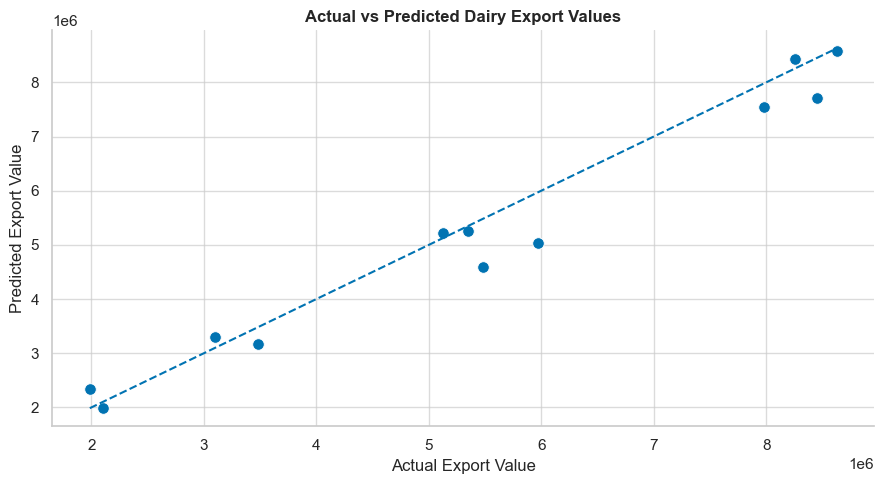

In [329]:
# Actual vs Predicted visualization
plt.figure(figsize=(9,5))

sns.scatterplot(data=diagnostic_df, x="Actual",y="Predicted",s=70)

# Perfect prediction reference line
min_val = min(diagnostic_df["Actual"].min(), diagnostic_df["Predicted"].min())
max_val = max(diagnostic_df["Actual"].max(), diagnostic_df["Predicted"].max())

plt.plot([min_val, max_val],[min_val, max_val],linestyle="--")

plt.title("Actual vs Predicted Dairy Export Values",fontsize=12,weight="semibold")

plt.xlabel("Actual Export Value")
plt.ylabel("Predicted Export Value")

plt.grid(axis="both", alpha=0.7)
sns.despine()
plt.tight_layout()


### Observation

The predictions remained reasonably close to the ideal prediction line, showing that Ridge Regression captured the overall export trends effectively. Although prediction errors became slightly larger for some high-export observations, the model maintained a balanced distribution of errors without significant systematic overprediction or underprediction. However, larger prediction errors for some high-export observations suggest that certain country-specific or sudden export variations were not fully captured by the linear model.

# Country-wise Residual Analysis

In [311]:
# Add country information to diagnostic dataframe
diagnostic_df["Country"] = test_df["country"].values

# Average residual by country
country_residuals = (
    diagnostic_df
    .groupby("Country")["Residuals"]
    .mean()
    .sort_values()
    .reset_index()
)

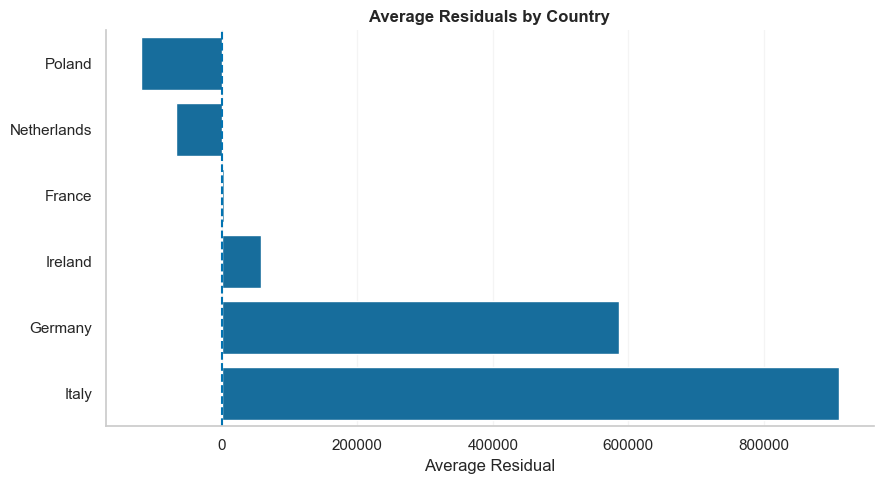

In [331]:
plt.figure(figsize=(9,5))

sns.barplot(data=country_residuals,x="Residuals",y="Country")

plt.axvline(x=0,linestyle="--")

plt.title("Average Residuals by Country",fontsize=12,weight="semibold")
plt.xlabel("Average Residual")
plt.ylabel("")

plt.grid(axis="x", alpha=0.2)
sns.despine()
plt.tight_layout()

### Observation
The residual analysis shows that Ridge Regression produced relatively balanced prediction errors for most countries, with France, Ireland, Netherlands, and Poland remaining close to zero residuals. However, larger positive residuals for Germany and especially Italy indicate that the model tended to underestimate export values for some larger dairy-exporting economies.

## Coefficient Interpretation

The standardized regression coefficients will now be examined to identify which variables contribute most strongly to dairy export forecasting performance.

Positive coefficients indicate variables associated with higher export values, while negative coefficients indicate inverse relationships with the target variable.

In [334]:
# Extract Ridge model coefficients
ridge_pipeline = baseline_models["Ridge"]

ridge_pipeline.fit(X_train, y_train)

ridge_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_pipeline.named_steps["model"].coef_
})

ridge_coefficients["Absolute Coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(by="Absolute Coefficient", ascending=False)
    .reset_index(drop=True)
)


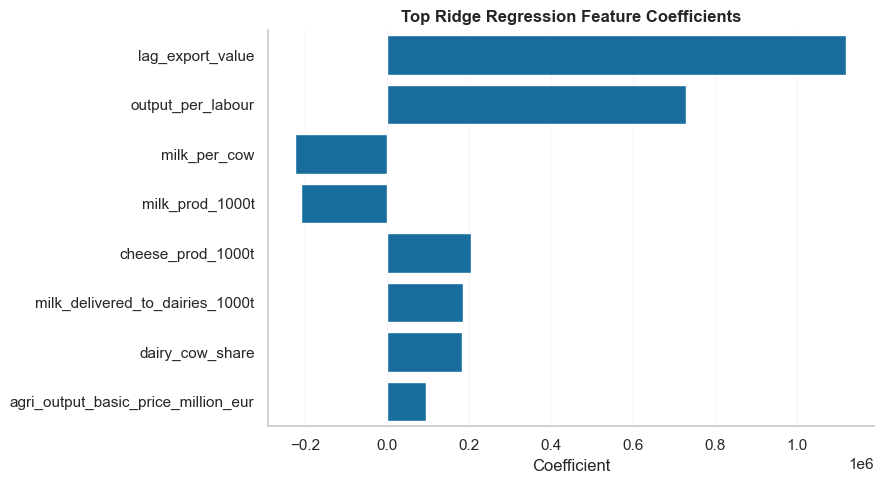

In [333]:
top_coefficients = ridge_coefficients.head(8)

plt.figure(figsize=(9,5))

sns.barplot(data=top_coefficients,x="Coefficient",y="Feature")

plt.title("Top Ridge Regression Feature Coefficients",fontsize=12,weight="semibold")
plt.xlabel("Coefficient")
plt.ylabel("")

plt.grid(axis="x", alpha=0.15)
sns.despine()
plt.tight_layout()

### Observation
The coefficient analysis confirms that `lag_export_value` was the dominant driver of predictions, reinforcing the earlier findings. `output_per_labour` also contributed strongly, suggesting that labour efficiency played an important role in explaining dairy export competitiveness across countries.

Negative coefficients for variables such as `milk_per_cow` and `milk_prod_1000t` indicate that some production-related variables shared overlapping information with stronger predictors, causing Ridge regularization to redistribute coefficient weights across correlated features rather than interpreting them independently.

# Conclusion

The results demonstrated that dairy export forecasting within the selected dataset is heavily influenced by temporal persistence indicating that historical export behaviour remains the strongest short-term predictor of future export performance. Although lag sensitivity analysis confirmed that production, productivity, and economic variables still contribute meaningful explanatory value but their contribution remains secondart to historical export persistence.

Among the models applied, regularized linear models particularly Ridge Regression and Linear Regression with encoded country information achieved the strongest overall performance. These findings suggest that the dataset is primarily governed by stable linear relationships and country-level structural patterns rather than highly complex nonlinear interactions. The experiments also showed that increasing model complexity did not necessarily improve forecasting performance. Tree-based ensemble models such as Random Forest were more sensitive to the relatively small country-year dataset and demonstrated weaker generalization stability after additional complexity expansion. This highlights the importance of balancing model flexibility with dataset size and temporal structure in forecasting-oriented workflows. 

Future work should focus on improving the model’s ability to add predictive value beyond the strong naive benchmark. One improvement would be to  use higher-frequency data like quarterly or monthly export records(which were not readily accessible online). Another possible extension would be to explore time-series-specific approaches such as ARIMAX, Prophet, or panel forecasting methods that combine lagged behaviour with external explanatory variables. These methods may prove to be more powerful; however, they were not explored within the scope of this module.